# CarDD — classification multi-label du type de dégât (ResNet18, transfer learning)

Objectif ADR 0006 : prédire quels **types de dégât** (dent, scratch, crack, glass shatter,
lamp broken, tire flat) sont présents sur une photo. **6 sorties sigmoïde** (multi-label).

Méthode : **ResNet18 pré-entraîné ImageNet, corps gelé + tête remplacée**, sur **MPS**.
Anti-surentraînement : gel du corps (peu de params), augmentation, early stopping, courbes val.
Déséquilibre : `BCEWithLogitsLoss(pos_weight=neg/pos)`. Métriques **par classe** (pas l'accuracy).

In [1]:
import sys; sys.path.insert(0, '../../src')
import importlib, cardd, device as devmod
importlib.reload(cardd); importlib.reload(devmod)
from cardd import CarDDMultiLabel, CLASSES
from device import get_device

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import precision_recall_fscore_support, f1_score

torch.manual_seed(42)
device = get_device(); print('device:', device)
COCO = '../../data/cardd/raw/CarDD_release/CarDD_COCO'
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

device: mps


In [2]:
# --- Transforms : augmentation douce en train (ne pas cropper le dégât), resize simple en eval ---
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = CarDDMultiLabel(COCO, 'train', train_tf)
val_ds   = CarDDMultiLabel(COCO, 'val',   eval_tf)
test_ds  = CarDDMultiLabel(COCO, 'test',  eval_tf)
print('train/val/test :', len(train_ds), len(val_ds), len(test_ds))

# num_workers=0 : fiable en nbconvert sur macOS (spawn). Lent mais sûr pour un 1er run.
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)

pos_weight = train_ds.pos_weight().to(device)
print('pos_weight par classe :', {c: round(float(w), 1) for c, w in zip(CLASSES, pos_weight)})

train/val/test : 2816 810 374
pos_weight par classe : {'dent': 1.3, 'scratch': 0.9, 'crack': 5.5, 'glass shatter': 5.0, 'lamp broken': 4.8, 'tire flat': 11.9}


In [3]:
# --- Modèle : ResNet18 pré-entraîné, corps gelé, tête -> 6 logits ---
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for p in model.parameters():
    p.requires_grad = False              # gel du corps
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))  # tête entraînable (6 sorties)
model = model.to(device)

n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('params entrainables (tete seule) :', n_train)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

params entrainables (tete seule) : 3078


In [4]:
# --- Boucle epoch. model.eval() en permanence : BN du corps gelée (stats ImageNet),
#     seule la tete apprend (grad via requires_grad). ---
def run_epoch(loader, train):
    model.eval()
    total = 0.0; ys = []; ps = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.set_grad_enabled(train):
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item() * x.size(0)
        ys.append(y.cpu()); ps.append(torch.sigmoid(logits).detach().cpu())
    y_true = torch.cat(ys).numpy(); y_prob = torch.cat(ps).numpy()
    return total / len(loader.dataset), y_true, y_prob

def macro_f1(y_true, y_prob, thr=0.5):
    return f1_score(y_true, (y_prob >= thr).astype(int), average='macro', zero_division=0)

In [5]:
# --- Entraînement + early stopping (patience 3 sur macro-F1 val) ---
EPOCHS, PATIENCE = 15, 3
hist = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_f1, best_state, wait = -1.0, None, 0

for ep in range(1, EPOCHS + 1):
    tr_loss, _, _ = run_epoch(train_dl, train=True)
    va_loss, y_true, y_prob = run_epoch(val_dl, train=False)
    vf1 = macro_f1(y_true, y_prob)
    hist['train_loss'].append(tr_loss); hist['val_loss'].append(va_loss); hist['val_f1'].append(vf1)
    print(f'epoch {ep:2d} | train {tr_loss:.3f} | val {va_loss:.3f} | val macroF1 {vf1:.3f}')
    if vf1 > best_f1:
        best_f1, wait = vf1, 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f'early stopping (best val macroF1 ={best_f1:.3f})'); break

model.load_state_dict(best_state)

epoch  1 | train 0.769 | val 0.644 | val macroF1 0.601


epoch  2 | train 0.580 | val 0.560 | val macroF1 0.644


epoch  3 | train 0.526 | val 0.526 | val macroF1 0.677


epoch  4 | train 0.498 | val 0.512 | val macroF1 0.673


epoch  5 | train 0.482 | val 0.520 | val macroF1 0.686


...

epoch  7 | train 0.459 | val 0.484 | val macroF1 0.716


epoch  8 | train 0.444 | val 0.485 | val macroF1 0.712


epoch  9 | train 0.440 | val 0.476 | val macroF1 0.701


epoch 10 | train 0.433 | val 0.479 | val macroF1 0.715
early stopping (best val macroF1 =0.716)


<All keys matched successfully>

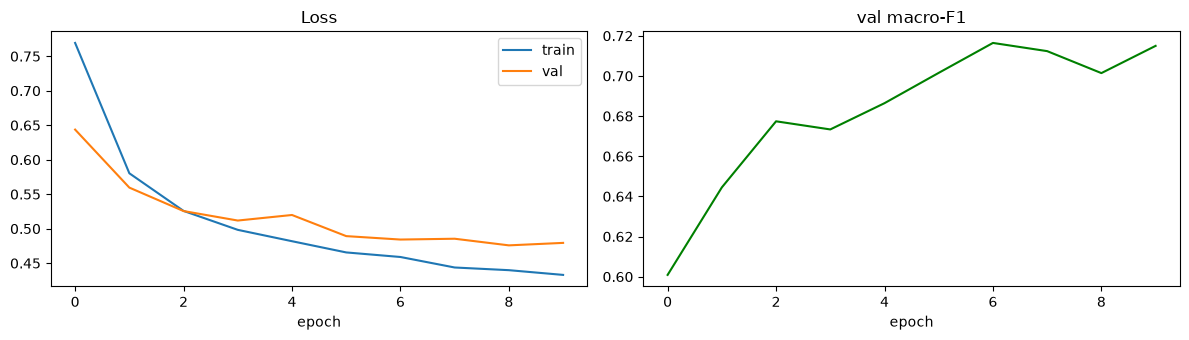

In [6]:
# --- Courbes train/val (surveiller l'overfitting) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(hist['train_loss'], label='train'); ax[0].plot(hist['val_loss'], label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(hist['val_f1'], color='green'); ax[1].set_title('val macro-F1'); ax[1].set_xlabel('epoch')
plt.tight_layout(); plt.show()

In [7]:
# --- Évaluation honnête sur le TEST : precision/recall/F1 PAR CLASSE (seuil 0.5) ---
_, yt, yp = run_epoch(test_dl, train=False)
pred = (yp >= 0.5).astype(int)
prec, rec, f1, sup = precision_recall_fscore_support(yt, pred, average=None, zero_division=0)
import pandas as pd
report = pd.DataFrame({'precision': prec, 'recall': rec, 'f1': f1, 'support': sup.astype(int)},
                      index=CLASSES).round(3)
print(report)
print()
print('macro-F1 :', round(f1.mean(), 3))
print('micro-F1 :', round(f1_score(yt, pred, average='micro', zero_division=0), 3))

               precision  recall     f1  support
dent               0.724   0.854  0.784      157
scratch            0.703   0.749  0.725      183
crack              0.303   0.479  0.371       48
glass shatter      0.878   0.915  0.897       71
lamp broken        0.469   0.815  0.596       65
tire flat          0.675   0.871  0.761       31

macro-F1 : 0.689
micro-F1 : 0.709


In [8]:
# --- Sauvegarde du modèle (dl/models/ gitignored) ---
MODELS = Path('../../models'); MODELS.mkdir(exist_ok=True)
torch.save({'state_dict': model.state_dict(), 'classes': CLASSES,
            'arch': 'resnet18', 'input': 224}, MODELS / 'cardd_multilabel_resnet18.pt')
print('modèle sauvé ->', MODELS / 'cardd_multilabel_resnet18.pt')

modèle sauvé -> ../../models/cardd_multilabel_resnet18.pt


## Lecture des résultats (honnête, BC04)

- Lire le **F1 par classe**, pas une accuracy globale (trompeuse en multi-label déséquilibré).
- Les classes rares (`tire flat`, `crack`) auront probablement un F1 plus faible → cohérent avec
  le déséquilibre (EDA / ADR 0006), à ne pas masquer.
- Corps gelé + peu de params → surentraînement limité ; vérifier quand même les courbes train/val.
- **Limite de généralisation** : entraîné sur photos stock "propres" → perf non garantie sur des
  photos d'annonce réelles (biais de source, ADR 0006). À tester sur de vraies photos avant tout
  usage produit.

Étapes suivantes possibles : fine-tuning (dégel partiel du corps, 5070 Ti), puis objectif **zones**
(détection/segmentation) — step 2.